# PSO-CamoPatch

Particle Swarm Optimization for adversarial patch generation. This notebook demonstrates patch optimization on a single image using PSO, then compares against baseline methods.

The patch is rendered as overlapping semi-transparent circles. Each circle is parameterized by center, radius, color, and alpha. The PSO swarm jointly optimizes patch placement and circle parameters to maximize model disruption while minimizing visual difference from the background.

In [1]:
# Environment setup
import torch
print(f"PyTorch {torch.__version__}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

PyTorch 2.12.0+cu126
Device: CUDA


In [2]:
# Imports
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve()))  # ensure src is here

import torch
import torchvision
from torchvision.models import ResNet50_Weights

from src.config import PSOConfig
from src.utils import preprocess_image, normalize_tensor
from src.palette import extract_palette_manual_kmeans
from src.visualize import visualize_palette
from src.pso import run

## Configuration

All experiment parameters are defined in a single configuration object. Key parameters control swarm size and generations, PSO coefficients, and patch structure. The gravity term (if nonzero) pulls patch colors toward dominant image colors to encourage camouflage.

In [3]:
IMAGE_URL = "https://github.com/EliSchwartz/imagenet-sample-images/blob/master/n02356798_fox_squirrel.JPEG?raw=true"

cfg = PSOConfig(
    image_source=IMAGE_URL,
    pop_size=100,
    generations=100,
    w=0.6,
    c1=1.5,
    c2=1.5,
    gravity=0.1,
    patch_size=40,
    num_circles=100,
    palette_size=16,
    tolerance=0.5,
)
print(cfg)

PSOConfig(image_source='https://github.com/EliSchwartz/imagenet-sample-images/blob/master/n02356798_fox_squirrel.JPEG?raw=true', img_size=224, patch_size=40, num_circles=100, pop_size=100, generations=100, w=0.6, c1=1.5, c2=1.5, gravity=0.1, palette_size=16, tolerance=0.5, device=device(type='cuda'))


## Load & Inspect the Target Image

Top-5 predictions (before attack):
  fox squirrel                   0.955
  grey fox                       0.008
  orangutan                      0.005
  wild boar                      0.002
  yellow lady's slipper          0.001


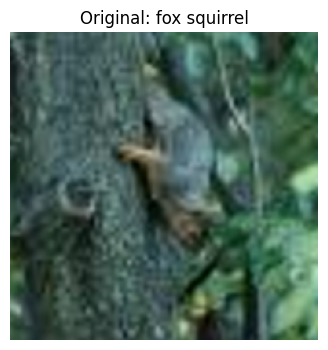

In [4]:
import matplotlib.pyplot as plt

_, cropped_pil, img_unnorm = preprocess_image(IMAGE_URL, cfg.img_size, cfg.device)

model = cfg.model_factory(weights=cfg.model_weights).eval().to(cfg.device)
imagenet_labels = cfg.model_weights.meta["categories"]

with torch.no_grad():
    probs = torch.softmax(model(normalize_tensor(img_unnorm)), dim=1)[0]

top5_idx = probs.topk(5).indices.tolist()
print("Top-5 predictions (before attack):")
for idx in top5_idx:
    print(f"  {imagenet_labels[idx]:<30} {probs[idx].item():.3f}")

plt.figure(figsize=(4, 4))
plt.imshow(cropped_pil)
plt.title(f"Original: {imagenet_labels[top5_idx[0]]}")
plt.axis("off")
plt.show()

## Extract Image Palette

The palette consists of K dominant colors extracted from the target image via K-Means. During PSO optimization, the gravity term pulls circle colors toward this palette, encouraging the patch to blend into natural image structure.

Extracted 16 colors via K-Means


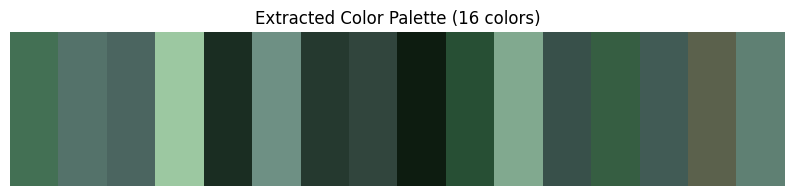

In [5]:
palette = extract_palette_manual_kmeans(cropped_pil, n_colors=cfg.palette_size)
print(f"Extracted {palette.shape[0]} colors via K-Means")
visualize_palette(palette)

## Run PSO Attack

The PSO swarm evolves a population of candidate patches. Each particle encodes patch parameters: top-left location, and per-circle details. Fitness is evaluated by applying the patch to the image and checking if the model misclassifies the result. If so, fitness is the squared L2 distance between patch and background; otherwise infinity.

Original prediction: fox squirrel (335) @ 0.9549
PSO: pop=100, gens=100, target='fox squirrel'
  gen   1/100 | best L2: 228.9740 | queries: 100
  gen   2/100 | best L2: 164.8740 | queries: 200
  gen   3/100 | best L2: 132.1433 | queries: 300
  gen   4/100 | best L2: 132.1433 | queries: 400
  gen   5/100 | best L2: 127.1060 | queries: 500
  gen   6/100 | best L2: 127.1060 | queries: 600
  gen   7/100 | best L2: 101.0763 | queries: 700
  gen   8/100 | best L2: 101.0763 | queries: 800
  gen   9/100 | best L2: 101.0763 | queries: 900
  gen  10/100 | best L2: 97.6873 | queries: 1000
  gen  11/100 | best L2: 91.1163 | queries: 1100
  gen  12/100 | best L2: 86.1616 | queries: 1200
  gen  13/100 | best L2: 86.1616 | queries: 1300
  gen  14/100 | best L2: 80.5930 | queries: 1400
  gen  15/100 | best L2: 69.9911 | queries: 1500
  gen  16/100 | best L2: 69.9911 | queries: 1600
  gen  17/100 | best L2: 69.9911 | queries: 1700
  gen  18/100 | best L2: 68.3365 | queries: 1800
  gen  19/100 | best L2

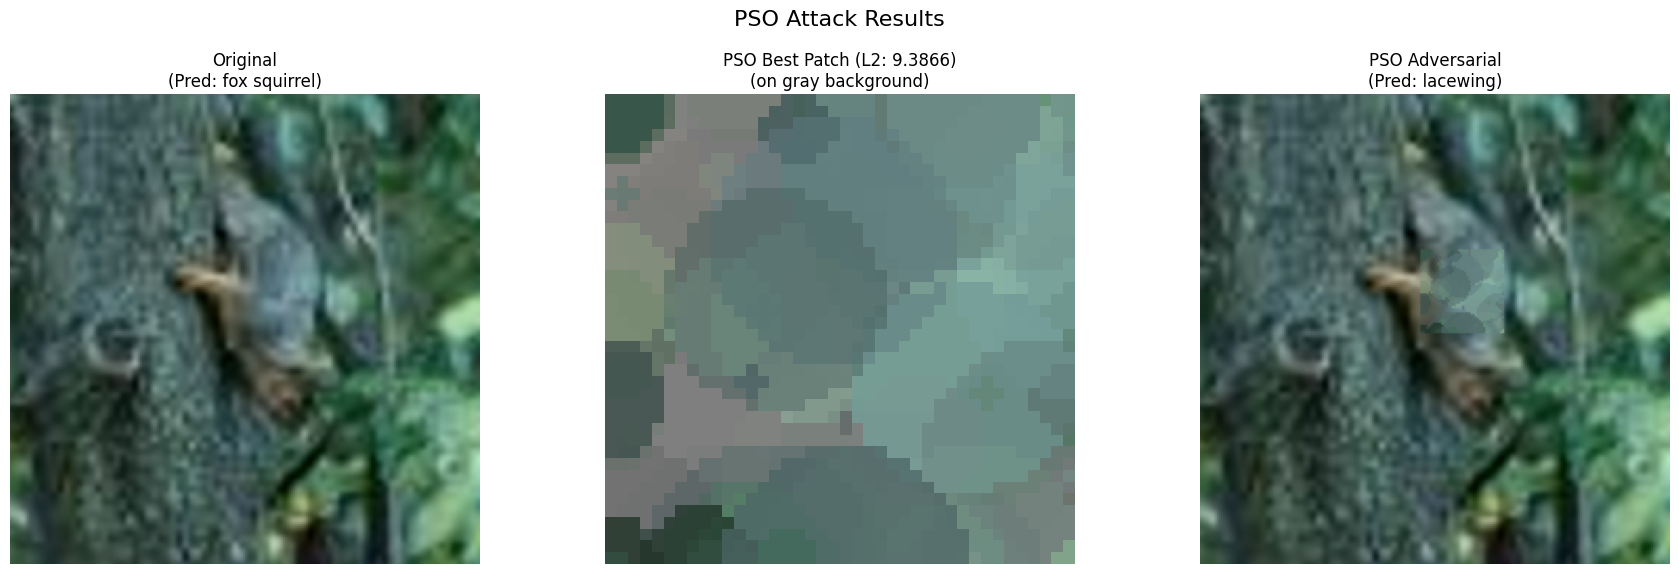

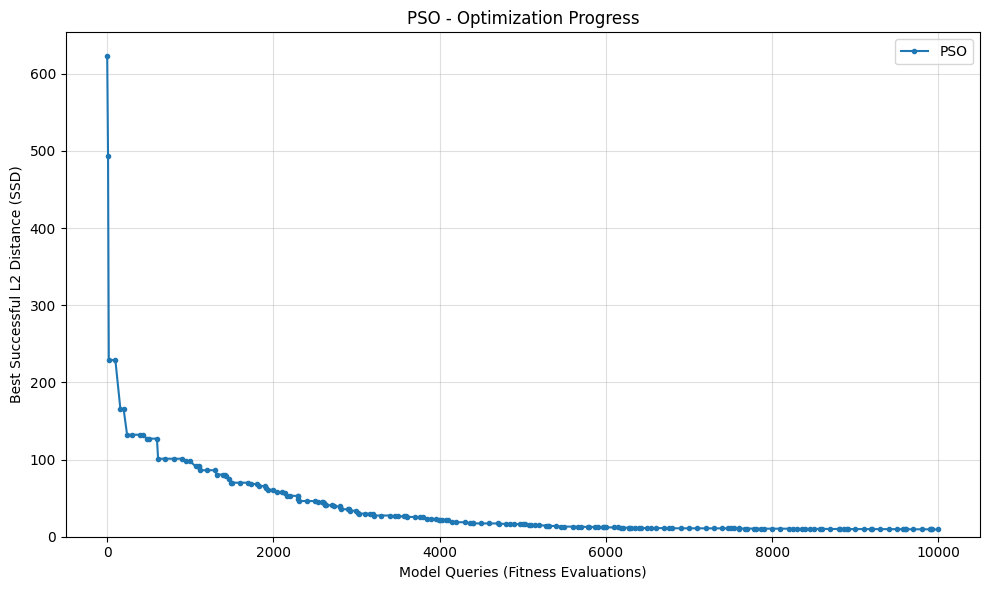


Attack succeeded.
Best patch L2 (SSD vs background): 9.3866


In [6]:
success, final_l2, pso_qh, pso_lh = run(cfg, plot=True)
print(f"\nAttack {'succeeded' if success else 'FAILED'}.")
if success:
    print(f"Best patch L2 (SSD vs background): {final_l2:.4f}")

## Baseline Comparison

PSO is compared against Random Search and Stochastic Hill Climbing using the same model query budget. All three methods are run once on the current image. For statistical comparison across multiple images and runs, see the experiment script.

In [7]:
from src.baselines import random_search, stochastic_hillclimber

budget = cfg.total_queries
print(f"Query budget: {budget}")

rs_success, rs_l2, rs_qh, rs_lh = random_search(
    IMAGE_URL, model, imagenet_labels,
    img_size=cfg.img_size, patch_size=cfg.patch_size,
    num_circles=cfg.num_circles, total_queries=budget, device=cfg.device,
)

shc_success, shc_l2, shc_qh, shc_lh = stochastic_hillclimber(
    IMAGE_URL, model, imagenet_labels,
    img_size=cfg.img_size, patch_size=cfg.patch_size,
    num_circles=cfg.num_circles, total_queries=budget, device=cfg.device,
)

print(f"\n{'Method':<10} {'Success':>8} {'L2':>10}")
print(f"{'PSO':<10} {str(success):>8} {final_l2:>10.4f}")
print(f"{'RS':<10} {str(rs_success):>8} {rs_l2:>10.4f}")
print(f"{'SHC':<10} {str(shc_success):>8} {shc_l2:>10.4f}")

Query budget: 10000
RS: original prediction 'fox squirrel'
RS done. Success=True, best L2=168.3323
SHC: original prediction 'fox squirrel'
SHC: no patch found.

Method      Success         L2
PSO            True     9.3866
RS             True   168.3323
SHC           False        inf


## Convergence Comparison

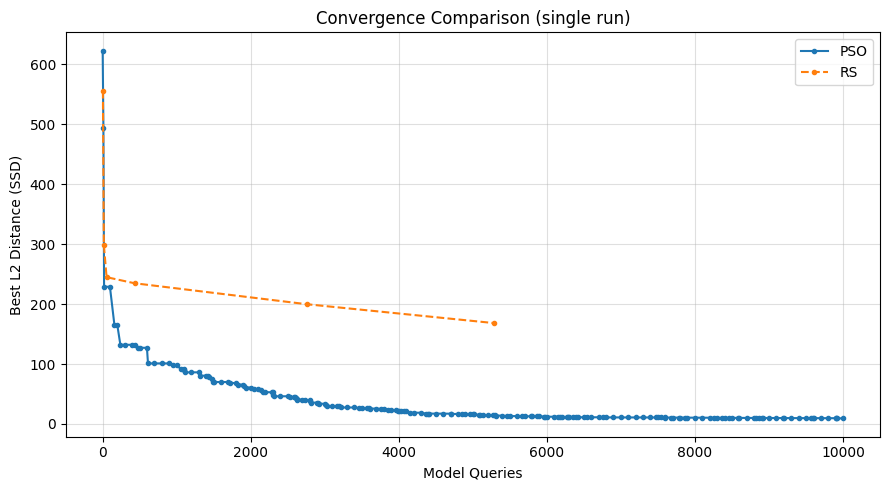

In [8]:
import matplotlib.pyplot as plt
import math

def _prep_curve(qh, lh):
    return [(q, l) for q, l in zip(qh, lh) if math.isfinite(l)]

plt.figure(figsize=(9, 5))
for label, qh, lh, ls in [("PSO", pso_qh, pso_lh, "-"),
                            ("RS", rs_qh, rs_lh, "--"),
                            ("SHC", shc_qh, shc_lh, ":")]:
    pts = _prep_curve(qh, lh)
    if pts:
        qs, ls2 = zip(*pts)
        plt.plot(qs, ls2, linestyle=ls, marker=".", label=label)

plt.xlabel("Model Queries")
plt.ylabel("Best L2 Distance (SSD)")
plt.title("Convergence Comparison (single run)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## Full Multi-Run Experiment

For formal results, use the experiment script to test multiple methods on multiple images with multiple random seeds. This produces summary statistics and statistical tests.

In [9]:
# Load and analyse saved results (run after experiments/run_comparison.py)
import pandas as pd
from pathlib import Path
from scipy import stats
import numpy as np

results_path = Path("results/results.csv")
if not results_path.exists():
    print("No results file yet. Run: python experiments/run_comparison.py")
else:
    df = pd.read_csv(results_path)
    df["l2"] = pd.to_numeric(df["l2"], errors="coerce")

    summary = (
        df.groupby("method")
        .apply(lambda g: pd.Series({
            "ASR": g["success"].eq(True).mean(),
            "Mean L2": g.loc[g["success"].eq(True), "l2"].mean(),
            "Median L2": g.loc[g["success"].eq(True), "l2"].median(),
            "Std L2": g.loc[g["success"].eq(True), "l2"].std(),
            "N": len(g),
        }))
    )
    print(summary.to_string())

    # Wilcoxon signed-rank test: PSO vs RS (paired by image)
    pso_df = df[df["method"] == "PSO"].sort_values(["image_idx", "run"]).reset_index(drop=True)
    rs_df  = df[df["method"] == "RS" ].sort_values(["image_idx", "run"]).reset_index(drop=True)
    paired = pso_df.merge(rs_df, on=["image_idx", "run"], suffixes=("_pso", "_rs"))
    paired = paired.dropna(subset=["l2_pso", "l2_rs"])
    if len(paired) >= 5:
        stat, p = stats.wilcoxon(paired["l2_pso"] - paired["l2_rs"], alternative="less")
        print(f"\nWilcoxon PSO < RS: p={p:.4f}")

             ASR     Mean L2   Median L2      Std L2     N
method                                                    
PSO     0.864865   27.065402   18.555434   26.988130  37.0
RS      0.972973  275.895265  246.494110  107.304581  37.0
SHC     0.513514  169.709757  146.485840  102.064901  37.0

Wilcoxon PSO < RS: p=nan


## Patch Placement Comparison (PSO vs Williams & Li)

This visualization compares patch center placement distributions across multiple runs between the proposed PSO method and the original CamoPatch (ES+SA) approach. Data below represents 5 independent runs on each test image.

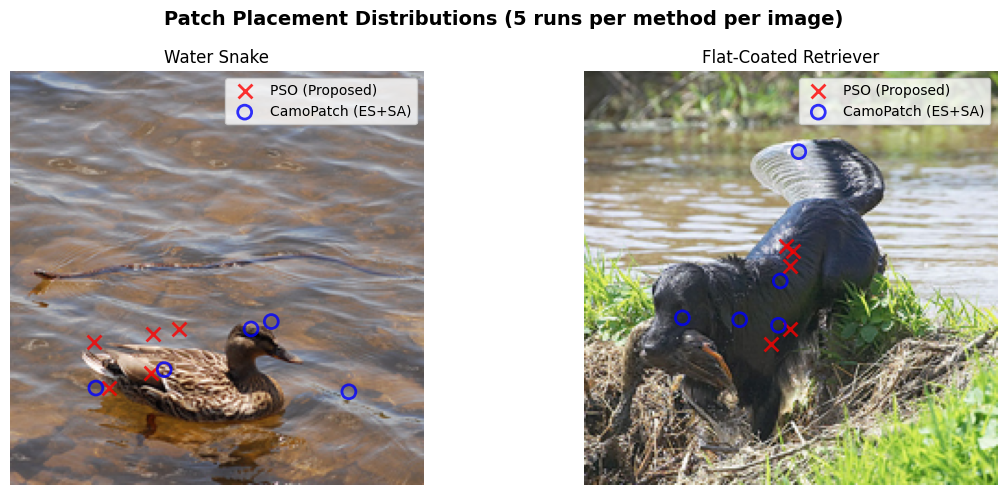

Placement consistency (tighter clustering = more consistent placement):
PSO Image 1 — X std: 16.89, Y std: 12.54
CamoPatch Image 1 — X std: 47.53, Y std: 15.93
PSO Image 2 — X std: 4.20, Y std: 22.16
CamoPatch Image 2 — X std: 22.46, Y std: 35.53


In [10]:
# Image URLs for placement study
img1_url = "https://github.com/EliSchwartz/imagenet-sample-images/blob/master/n01737021_water_snake.JPEG?raw=true"
img2_url = "https://github.com/EliSchwartz/imagenet-sample-images/blob/master/n02099267_flat-coated_retriever.JPEG?raw=true"

# Patch center coordinates from 5 runs each (experimental data collected empirically)
# PSO method (Proposed)
pso_x1 = [77, 45, 91, 53, 76]
pso_y1 = [142, 146, 139, 171, 163]
pso_x2 = [101, 109, 111, 111, 113]
pso_y2 = [147, 94, 139, 105, 97]

# CamoPatch ES+SA method (Williams & Li)
camopatch_x1 = [83, 130, 141, 183, 46]
camopatch_y1 = [161, 139, 135, 173, 171]
camopatch_x2 = [53, 105, 106, 116, 84]
camopatch_y2 = [133, 137, 113, 43, 134]

# Load images
_, img1_pil, _ = preprocess_image(img1_url, cfg.img_size, cfg.device)
_, img2_pil, _ = preprocess_image(img2_url, cfg.img_size, cfg.device)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Image 1
ax1.imshow(img1_pil)
ax1.scatter(pso_x1, pso_y1, marker="x", color="red", s=100, alpha=0.8, linewidth=2, label="PSO (Proposed)")
ax1.scatter(camopatch_x1, camopatch_y1, marker="o", edgecolors="blue", facecolors="none", s=100, alpha=0.8, linewidth=2, label="CamoPatch (ES+SA)")
ax1.set_title("Water Snake")
ax1.axis("off")
ax1.legend(loc="upper right")

# Image 2
ax2.imshow(img2_pil)
ax2.scatter(pso_x2, pso_y2, marker="x", color="red", s=100, alpha=0.8, linewidth=2, label="PSO (Proposed)")
ax2.scatter(camopatch_x2, camopatch_y2, marker="o", edgecolors="blue", facecolors="none", s=100, alpha=0.8, linewidth=2, label="CamoPatch (ES+SA)")
ax2.set_title("Flat-Coated Retriever")
ax2.axis("off")
ax2.legend(loc="upper right")

fig.suptitle("Patch Placement Distributions (5 runs per method per image)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Placement consistency (tighter clustering = more consistent placement):")
print(f"PSO Image 1 — X std: {np.std(pso_x1):.2f}, Y std: {np.std(pso_y1):.2f}")
print(f"CamoPatch Image 1 — X std: {np.std(camopatch_x1):.2f}, Y std: {np.std(camopatch_y1):.2f}")
print(f"PSO Image 2 — X std: {np.std(pso_x2):.2f}, Y std: {np.std(pso_y2):.2f}")
print(f"CamoPatch Image 2 — X std: {np.std(camopatch_x2):.2f}, Y std: {np.std(camopatch_y2):.2f}")